In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import numpy as np

In [5]:
df = pd.read_csv('/content/drive/MyDrive/data/spam.csv', encoding='ISO-8859-1')

In [6]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [7]:
df.shape

(5572, 5)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [9]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [10]:
df.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis=1,inplace=True)

In [12]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
df.rename(columns={'v1':'target', 'v2':'text'}, inplace=True)

In [14]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
encoder = LabelEncoder()

In [17]:
df['target'] = encoder.fit_transform(df['target'])

In [18]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [19]:
df.isna().sum()


target    0
text      0
dtype: int64

In [20]:
df.duplicated().sum()

403

In [21]:
df.drop_duplicates(keep='first',inplace=True)

In [22]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
df.shape

(5169, 2)

In [24]:
df['target'].value_counts()

0    4516
1     653
Name: target, dtype: int64

In [25]:
import matplotlib.pyplot as plt

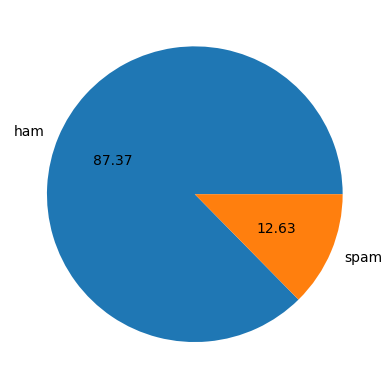

In [26]:
plt.pie(df['target'].value_counts(),labels=['ham','spam'], autopct='%0.2f')
plt.show()

In [27]:
import nltk

In [28]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [29]:
df['num_characters'] = df['text'].apply(len)

In [30]:
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))

In [31]:
df['num_sents'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [32]:
df[['num_characters','num_words','num_sents']].describe()

,num_characters,num_words,num_sents
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [33]:
df[df['target']==1][['num_characters','num_words','num_sents']].describe()

,num_characters,num_words,num_sents
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [34]:
df[df['target']==0][['num_characters','num_words','num_sents']].describe()

,num_characters,num_words,num_sents
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [35]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

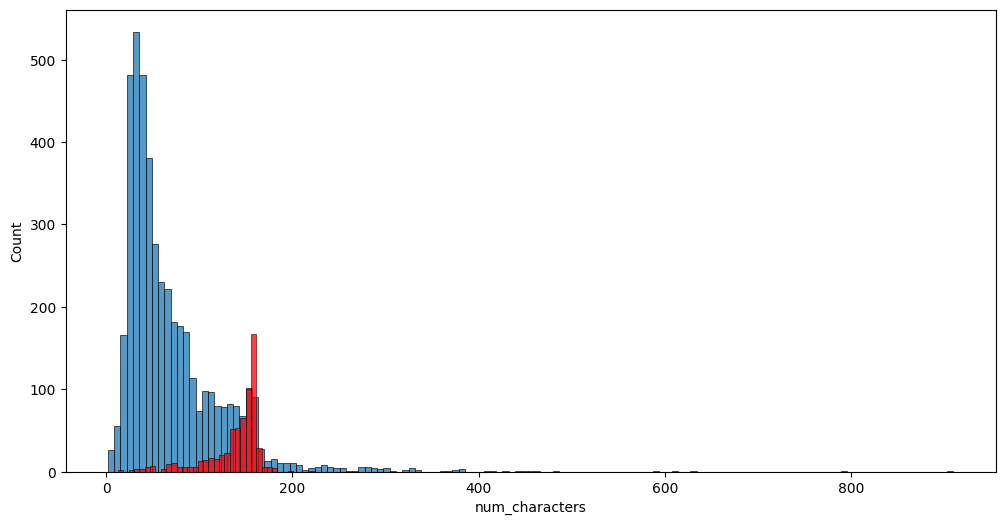

In [36]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_characters'])
sns.histplot(df[df['target'] == 1]['num_characters'], color='red')

<Axes: xlabel='num_words', ylabel='Count'>

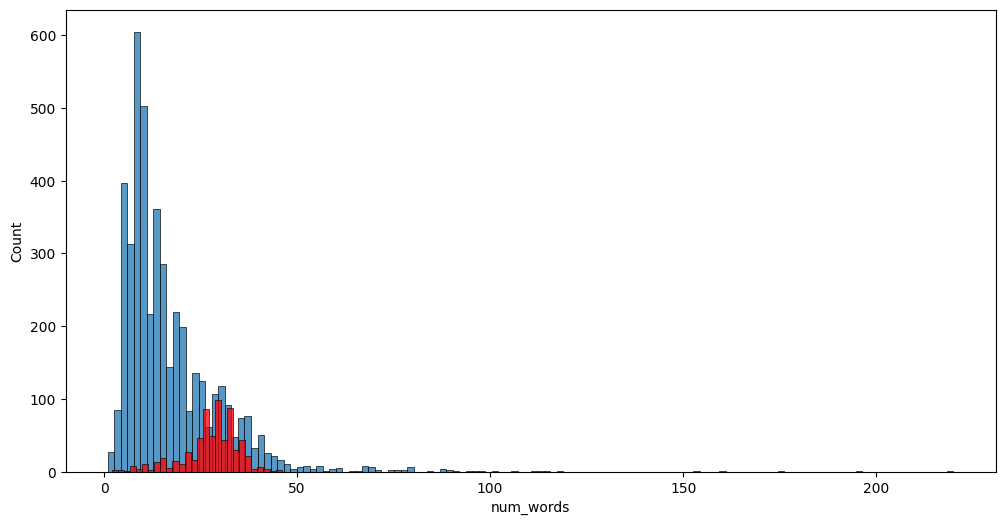

In [38]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['num_words'])
sns.histplot(df[df['target'] == 1]['num_words'], color='red')

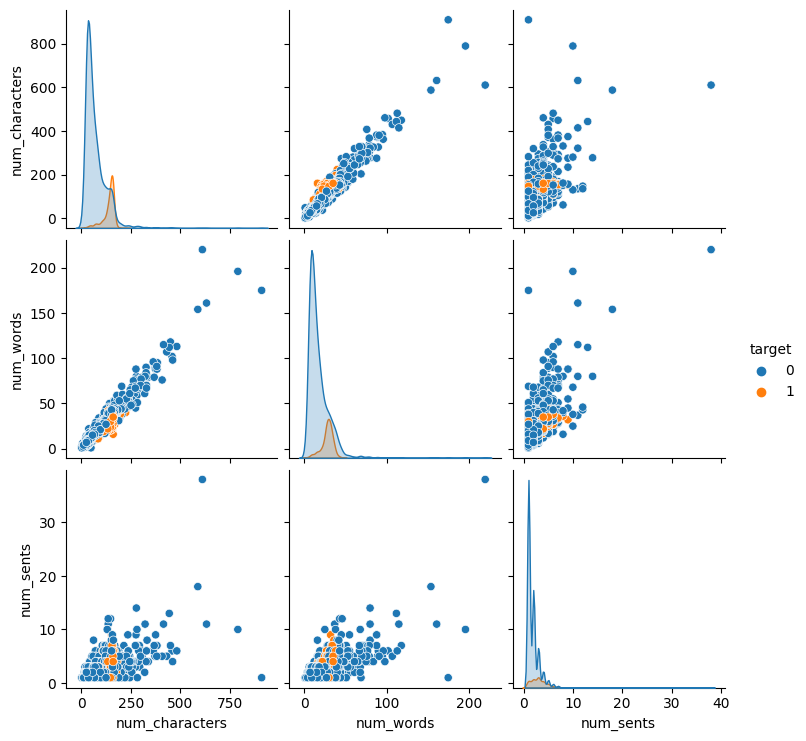

In [39]:
sns.pairplot(df,hue='target')

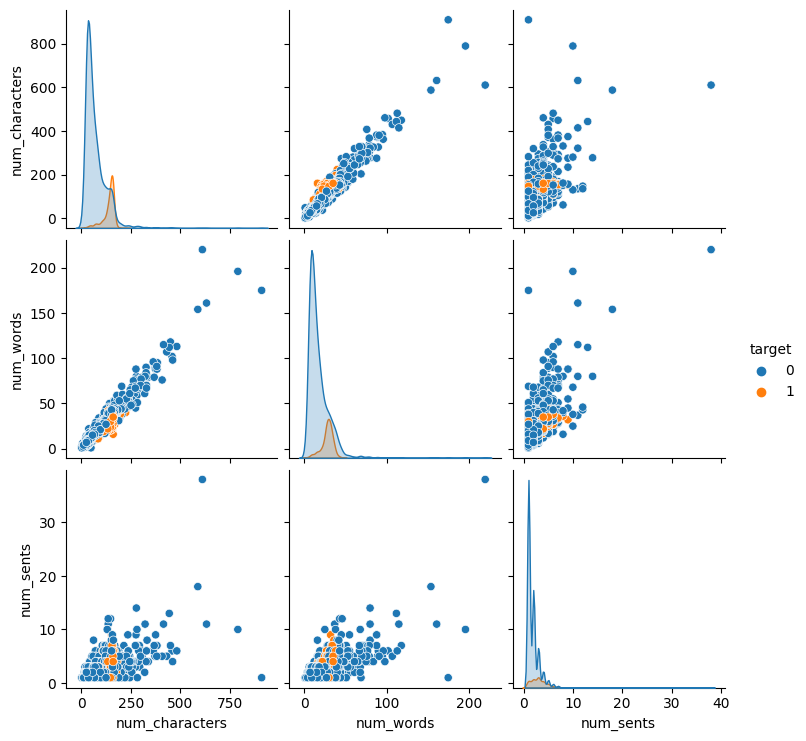

In [40]:
sns.pairplot(df,hue='target')

<ipython-input-41-8df7bcac526d>:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df.corr(),annot=True)


<Axes: >

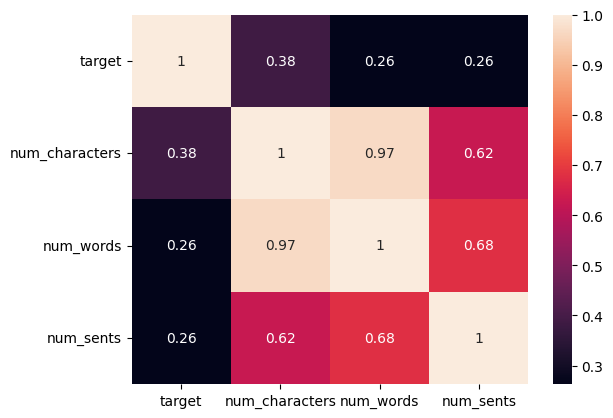

In [41]:
sns.heatmap(df.corr(),annot=True)

In [43]:
from nltk.corpus import stopwords

In [44]:
import string

In [45]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [52]:
from nltk.stem import PorterStemmer

In [70]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [74]:
def transform_text(text):
  text = text.lower()
  text =  nltk.sent_tokenize(text)
  text = [nltk.word_tokenize(sent) for sent in text]
  dup = []
  for i in text:
    for j in i:
      dup.append(j)
  text = dup.copy()
  dup.clear()
  for i in text:
    if i.isalnum():
      dup.append(i)
  text = dup.copy()
  dup.clear()
  quitwords = stopwords.words('english')
  punct = string.punctuation
  for i in text:
    if i not in quitwords and i not in punct:
      dup.append(i)
  text = dup.copy()
  dup.clear()
  ps = PorterStemmer()
  for i in text:
    dup.append(ps.stem(i))
  text = dup.copy()
  dup.clear()
  text = ' '.join(text)
  return text


In [75]:
df['trans_text'] = df['text'].apply(transform_text)

In [76]:
df.head()

,target,text,num_characters,num_words,num_sents,trans_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [79]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color = 'white')

In [80]:
spam_wc = wc.generate(df[df['target']==1]['trans_text'].str.cat(sep=' '))

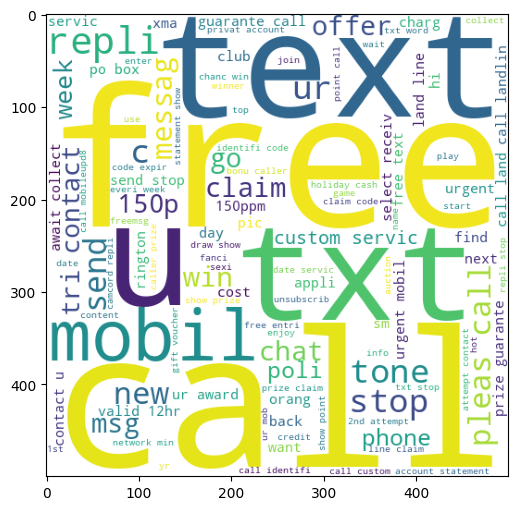

In [81]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [82]:
ham_wc = wc.generate(df[df['target']==0]['trans_text'].str.cat(sep=' '))

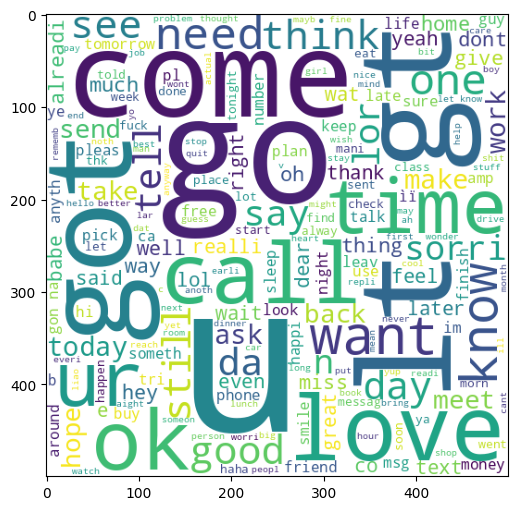

In [83]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [93]:
spam_corpus = []
for text in df[df['target']==1]['trans_text'].tolist():
  for word in text.split():
    spam_corpus.append(word)

In [85]:
len(spam_corpus)

9939

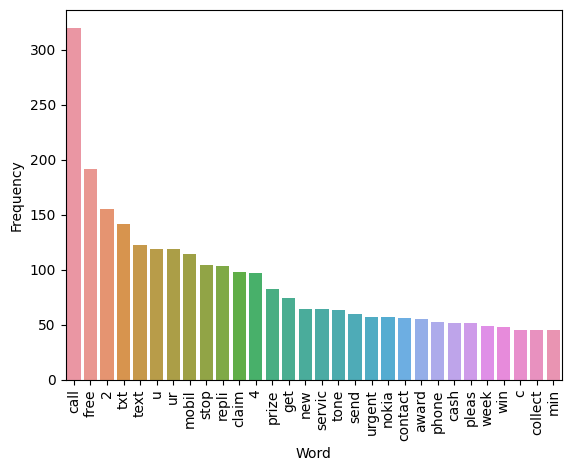

In [96]:
from collections import Counter
common_spam = Counter(spam_corpus).most_common(30)
df_common_spam = pd.DataFrame(common_spam, columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=df_common_spam)
plt.xticks(rotation='vertical')
plt.show()


In [98]:
ham_corpus = []
for text in df[df['target']==0]['trans_text'].tolist():
  for word in text.split():
    ham_corpus.append(word)

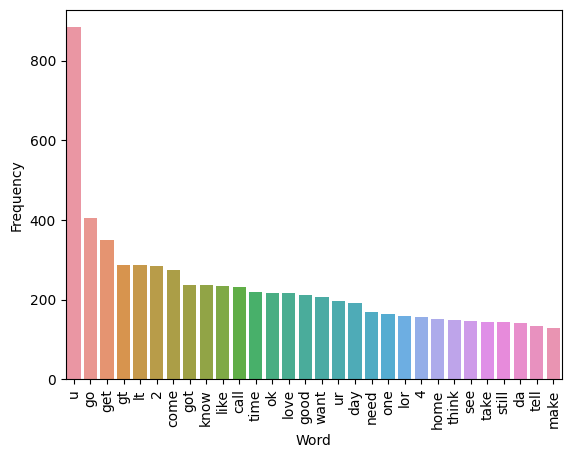

In [101]:
common_ham = Counter(ham_corpus).most_common(30)
df_common_ham = pd.DataFrame(common_ham, columns=['Word', 'Frequency'])
sns.barplot(x='Word', y='Frequency', data=df_common_ham)
plt.xticks(rotation='vertical')
plt.show()

In [102]:
df.head()

,target,text,num_characters,num_words,num_sents,trans_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [103]:
from sklearn.feature_extraction.text import CountVectorizer

In [104]:
cv = CountVectorizer()
X = cv.fit_transform(df['trans_text']).toarray()

In [105]:
X.shape

(5169, 6708)

In [106]:
df.shape

(5169, 6)

In [109]:
y = df['target'].values

In [110]:
y

array([0, 0, 1, ..., 0, 0, 0])

In [111]:
from sklearn.model_selection import train_test_split

In [124]:
df.target.value_counts()

0    4516
1     653
Name: target, dtype: int64

In [130]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20, random_state=42)

In [154]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [155]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [158]:
cv = CountVectorizer()
X = cv.fit_transform(df['trans_text']).toarray()
y = df['target'].values
gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [133]:
from sklearn.utils import resample

# Let's assume you have a dataframe named df and a column 'label' which marks spam as 1 and ham as 0.

# Separate the majority and minority classes
df_majority = df[df.target == 0]  # Assuming 0 is for 'ham' which is the majority class
df_minority = df[df.target == 1]  # Assuming 1 is for 'spam' which is the minority class

# Upsample the minority class
df_minority_upsampled = resample(df_minority,
                                 replace=True,               # sample with replacement
                                 n_samples=len(df_majority), # match the number in majority class
                                 random_state=42)            # reproducible results

# Combine the majority class with the upsampled minority class
df_upsampled = pd.concat([df_majority, df_minority_upsampled])

# Display new class counts
df_upsampled.target.value_counts()


0    4516
1    4516
Name: target, dtype: int64

In [134]:
df_upsampled.head()

,target,text,num_characters,num_words,num_sents,trans_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though
6,0,Even my brother is not like to speak with me. ...,77,18,2,even brother like speak treat like aid patent


In [135]:
x = cv.fit_transform(df_upsampled['trans_text']).toarray()
Y = df_upsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
gnb.fit(x_train,Y_train)
Y_pred = gnb.predict(x_test)
accuracy_score(Y_test,Y_pred)


0.9280575539568345

In [137]:
df_majority = df[df.target == 0]  # Assuming 0 is for 'ham' which is the majority class
df_minority = df[df.target == 1]  # Assuming 1 is for 'spam' which is the minority class

# Downsample the majority class
df_majority_downsampled = resample(df_majority,
                                   replace=False,             # without replacement, i.e., no repeated rows
                                   n_samples=len(df_minority), # match number in minority class
                                   random_state=42)           # reproducible results

# Combine minority class with the downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Display new class counts
df_downsampled.target.value_counts()


0    653
1    653
Name: target, dtype: int64

In [139]:
x = cv.fit_transform(df_downsampled['trans_text']).toarray()
Y = df_downsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
gnb.fit(x_train,Y_train)
Y_pred = gnb.predict(x_test)
accuracy_score(Y_test,Y_pred)

0.950381679389313

In [159]:
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [143]:
x = cv.fit_transform(df_upsampled['trans_text']).toarray()
Y = df_upsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
mnb.fit(x_train,Y_train)
Y_pred = mnb.predict(x_test)
accuracy_score(Y_test,Y_pred)


0.9789706696181516

In [144]:
x = cv.fit_transform(df_downsampled['trans_text']).toarray()
Y = df_downsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
mnb.fit(x_train,Y_train)
Y_pred = mnb.predict(x_test)
accuracy_score(Y_test,Y_pred)

0.9312977099236641

In [160]:
bnb.fit(X_train,y_train)
y_pred = bnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9661508704061895
[[885   4]
 [ 31 114]]
0.9661016949152542


In [147]:
x = cv.fit_transform(df_upsampled['trans_text']).toarray()
Y = df_upsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
bnb.fit(x_train,Y_train)
Y_pred = bnb.predict(x_test)
accuracy_score(Y_test,Y_pred)

0.9822910902047592

In [148]:
x = cv.fit_transform(df_downsampled['trans_text']).toarray()
Y = df_downsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
bnb.fit(x_train,Y_train)
Y_pred = bnb.predict(x_test)
accuracy_score(Y_test,Y_pred)

0.9351145038167938

In [149]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [150]:
tfidf = TfidfVectorizer()

In [161]:
X = tfidf.fit_transform(df['trans_text']).toarray()
y = df['target'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20, random_state=42)
gnb.fit(X_train,y_train)
y_pred = gnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.8636363636363636
[[772 117]
 [ 24 121]]
0.5084033613445378


In [162]:
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)
accuracy_score(y_test,y_pred)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9613152804642167
[[888   1]
 [ 39 106]]
0.9906542056074766


In [163]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['trans_text']).toarray()
y = df['target'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20, random_state=42)
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)
accuracy_score(y_test,y_pred)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [164]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [165]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [166]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [167]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    return accuracy,precision

In [168]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.97678916827853
Precision -  0.9548872180451128
For  KN
Accuracy -  0.9168278529980658
Precision -  1.0
For  NB
Accuracy -  0.9729206963249516
Precision -  0.9915966386554622
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8275862068965517
For  LR
Accuracy -  0.9468085106382979
Precision -  0.8688524590163934
For  RF
Accuracy -  0.9729206963249516
Precision -  0.9834710743801653
For  AdaBoost
Accuracy -  0.9506769825918762
Precision -  0.8671875
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.8840579710144928
For  ETC
Accuracy -  0.97678916827853
Precision -  0.991869918699187
For  GBDT
Accuracy -  0.9468085106382979
Precision -  0.96875
For  xgb
Accuracy -  0.9671179883945842
Precision -  0.937007874015748


In [169]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [170]:
performance_df

,Algorithm,Accuracy,Precision
1,KN,0.916828,1.000000
8,ETC,0.976789,0.991870
2,NB,0.972921,0.991597
5,RF,0.972921,0.983471
9,GBDT,0.946809,0.968750
0,SVC,0.976789,0.954887
10,xgb,0.967118,0.937008
7,BgC,0.962282,0.884058
4,LR,0.946809,0.868852
6,AdaBoost,0.950677,0.867188


In [171]:
import pickle as pkl

In [172]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['trans_text']).toarray()
y = df['target'].values
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=.20, random_state=42)
mnb.fit(X_train,y_train)
y_pred = mnb.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(precision_score(y_test,y_pred))

0.9729206963249516
[[888   1]
 [ 27 118]]
0.9915966386554622


In [174]:
pkl.dump(tfidf,open('vectorizer.pkl','wb'))
pkl.dump(mnb,open('model.pkl','wb'))

In [175]:
# for imbalanced dataset we have to look for precision

In [180]:
tfidf = TfidfVectorizer(max_features=3000)
x = tfidf.fit_transform(df_upsampled['trans_text']).toarray()
Y = df_upsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
mnb.fit(x_train,Y_train)
Y_pred = mnb.predict(x_test)
print(accuracy_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))
print(precision_score(Y_test,Y_pred))

0.9645821804095185
[[878  24]
 [ 40 865]]
0.9730033745781778


In [179]:
tfidf = TfidfVectorizer(max_features=3000)
x = tfidf.fit_transform(df_downsampled['trans_text']).toarray()
Y = df_downsampled['target'].values
x_train,x_test,Y_train,Y_test = train_test_split(x,Y,test_size=.20, random_state=42)
mnb.fit(x_train,Y_train)
Y_pred = mnb.predict(x_test)
print(accuracy_score(Y_test,Y_pred))
print(confusion_matrix(Y_test,Y_pred))
print(precision_score(Y_test,Y_pred))

0.9389312977099237
[[125   8]
 [  8 121]]
0.937984496124031
